In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

df = pd.read_csv('../documents/data/clean/RelacionesPersonales(limpio).csv')

# Variables numéricas para el clustering

cols_clustering = ['habilidadSocial', 'amigos', 'enfoque', 'noviazgo',
                   'tiempoSoltero', 'participacion', 'comunicacion',
                   'colaborativo', 'integracion', 'energiaInterpersonal']

X = df[cols_clustering].fillna(0) # Manejo de nulos básico

# Escalamiento
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

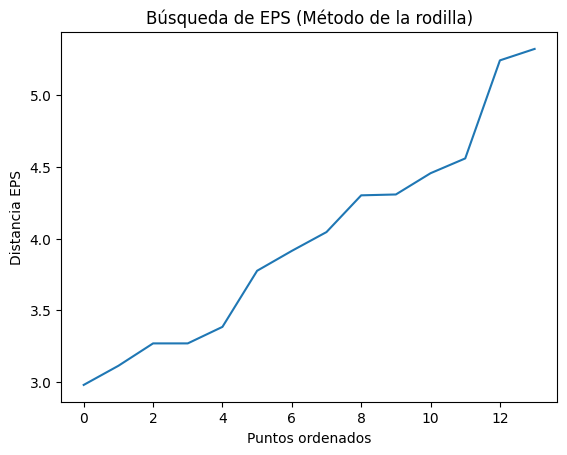

In [ ]:
# Calcular distancias al vecino más cercano (usaremos min_samples=5 como base)
neighbors = NearestNeighbors(n_neighbors=5)
neighbors_fit = neighbors.fit(X_scaled)
distances, indices = neighbors_fit.kneighbors(X_scaled)

# Graficar para encontrar el "codo"

distances = np.sort(distances[:, 4], axis=0)
plt.plot(distances)
plt.title('Búsqueda de EPS (Método de la rodilla)')
plt.xlabel('Puntos ordenados')
plt.ylabel('Distancia EPS')
plt.show()

In [ ]:

# Ajusta eps según el gráfico de arriba
dbscan = DBSCAN(eps=3.8, min_samples=2)
clusters = dbscan.fit_predict(X_scaled)

# Añadir etiquetas al dataframe original
df['Cluster'] = clusters

# 5. Ver resultados
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)
n_noise = list(clusters).count(-1)

print(f"Clusters encontrados: {n_clusters}")
print(f"Puntos de ruido (outliers): {n_noise}")

# 6. PERFILAMIENTO (Esto lo pide tu entrega)
perfilamiento = df.groupby('Cluster')[cols_clustering].mean()
print(perfilamiento)

Clusters encontrados: 2
Puntos de ruido (outliers): 2
         habilidadSocial  amigos   enfoque  noviazgo  tiempoSoltero  \
Cluster                                                               
-1              1.500000     0.5  0.500000  0.000000       5.500000   
 0              2.777778     1.0  0.666667  0.666667       1.625000   
 1              4.000000     0.0  0.333333  0.333333       2.666667   

         participacion  comunicacion  colaborativo  integracion  \
Cluster                                                           
-1            1.000000      0.500000      0.000000          4.0   
 0            0.666667      0.777778      0.666667          4.0   
 1            2.000000      1.000000      0.666667          3.0   

         energiaInterpersonal  
Cluster                        
-1                   2.000000  
 0                   1.555556  
 1                   4.000000  
